# Full EHRShot → TrajGPT pipeline

This notebook runs end-to-end with minimal code:
1. Build `processed_pophr_data.csv` + `vocab.json` from `data/data.parquet`
2. Build `phecode_embeddings.csv`
3. Build per-task labels from `data/labels/*/labels.parquet`
4. Fine-tune TrajGPT per benchmark task
5. Save benchmark figures to `benchmark/figures/`

Notes:
- For compatibility with the current TrajGPT BCE head, all tasks are binarized as `value > 0`.
- This notebook intentionally keeps logic short and centralized.

In [8]:
from pathlib import Path
import json
import re
import sys
import time
import shutil
import subprocess

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


ROOT = Path('.').resolve()
DATA_DIR = ROOT / 'data'
TRAJ_DATA_DIR = ROOT / 'TrajGPT_Code' / 'data'
BENCH_DIR = ROOT / 'benchmark'
FIG_DIR = BENCH_DIR / 'figures'
FIG_DIR.mkdir(parents=True, exist_ok=True)

# Runtime knobs
EPOCHS = 2
BATCH_SIZE = 32
SEQ_LEN = 256
D_MODEL = 200
CHECKPOINT_PATH = None  # e.g. ROOT / 'checkpoints' / 'model.pth'
USE_TASK_SAMPLE = 1000  # e.g. 50000 for faster debugging

print('ROOT:', ROOT)
print('DATA_DIR exists:', DATA_DIR.exists())


ROOT: /Users/adrienbelanger/Library/GitHub/TrajGPT-EHRSHOT
DATA_DIR exists: True


In [9]:
# 1) EHRShot MEDS -> TrajGPT event format
raw_path = DATA_DIR / 'data.parquet'
assert raw_path.exists(), f'Missing: {raw_path}'

df = pd.read_parquet(raw_path, columns=['subject_id', 'time', 'code'])
df['time'] = pd.to_datetime(df['time'])
df = df.sort_values(['subject_id', 'time'])

codes = df['code'].drop_duplicates().tolist()
code_to_int = {code: i + 1 for i, code in enumerate(codes)}
df['PheCode'] = df['code'].map(code_to_int).astype('int32')

first_times = df.groupby('subject_id')['time'].transform('min')
df['age_at_diag'] = ((df['time'] - first_times).dt.days / 30.44).fillna(0).astype('int16')

events = df.rename(columns={'subject_id': 'id', 'time': 'date', 'code': 'icd'})
events['Phenotype'] = events['icd']
events['month_of_birth'] = '1900-01-01'
events = events[['id', 'date', 'icd', 'PheCode', 'Phenotype', 'month_of_birth', 'age_at_diag']]

TRAJ_DATA_DIR.mkdir(parents=True, exist_ok=True)
events.to_csv(TRAJ_DATA_DIR / 'processed_pophr_data.csv', index=False)
with open(TRAJ_DATA_DIR / 'vocab.json', 'w') as f:
    json.dump(code_to_int, f)

print('Saved:', TRAJ_DATA_DIR / 'processed_pophr_data.csv')
print('Saved:', TRAJ_DATA_DIR / 'vocab.json')
print('Events:', len(events), '| Patients:', events['id'].nunique(), '| Codes:', len(code_to_int))


Saved: /Users/adrienbelanger/Library/GitHub/TrajGPT-EHRSHOT/TrajGPT_Code/data/processed_pophr_data.csv
Saved: /Users/adrienbelanger/Library/GitHub/TrajGPT-EHRSHOT/TrajGPT_Code/data/vocab.json
Events: 41661637 | Patients: 6739 | Codes: 31252


In [10]:
# 2) Build random token embeddings (shape must match d_model)
with open(TRAJ_DATA_DIR / 'vocab.json', 'r') as f:
    vocab = json.load(f)

rng = np.random.default_rng(42)
emb = rng.normal(scale=0.1, size=(len(vocab) + 1, D_MODEL))
emb_df = pd.DataFrame(emb, columns=[f'dim_{i}' for i in range(D_MODEL)])
emb_df.insert(0, 'phecode', np.arange(len(vocab) + 1))
emb_df.to_csv(TRAJ_DATA_DIR / 'phecode_embeddings.csv', index=False)

print('Saved:', TRAJ_DATA_DIR / 'phecode_embeddings.csv', '| shape:', emb_df.shape)


Saved: /Users/adrienbelanger/Library/GitHub/TrajGPT-EHRSHOT/TrajGPT_Code/data/phecode_embeddings.csv | shape: (31253, 201)


In [11]:
# 3) Build task label tables from data/labels/*/labels.parquet
def _choose_value_column(df: pd.DataFrame, task: str) -> str:
    candidates = [
        'value',
        'label',
        'target',
        'boolean_value',
        'integer_value',
        'float_value',
        'categorical_value',
    ]
    available = [c for c in candidates if c in df.columns]
    non_empty = [c for c in available if df[c].notna().any()]
    if not non_empty:
        raise ValueError(f'No non-null label column found for task={task}. Columns={list(df.columns)}')
    return non_empty[0]

def normalize_label_df(df: pd.DataFrame, task: str) -> pd.DataFrame:
    rename = {}
    if 'subject_id' in df.columns:
        rename['subject_id'] = 'patient_id'
    if 'time' in df.columns:
        rename['time'] = 'prediction_time'
    df = df.rename(columns=rename)

    if 'value' not in df.columns:
        value_source = _choose_value_column(df, task)
        df = df.rename(columns={value_source: 'value'})
    else:
        value_source = 'value'

    if 'prediction_time' not in df.columns:
        candidate = next((c for c in ['label_time', 'event_time'] if c in df.columns), None)
        if candidate is None:
            raise ValueError(f'No prediction_time column found for task={task}. Columns={list(df.columns)}')
        df = df.rename(columns={candidate: 'prediction_time'})

    if 'patient_id' not in df.columns:
        raise ValueError(f'No patient_id column found for task={task}. Columns={list(df.columns)}')

    out = df[['patient_id', 'prediction_time', 'value']].copy()
    out['prediction_time'] = pd.to_datetime(out['prediction_time'])

    # Binarize (needed by current TrajGPT BCE head)
    v = out['value']
    if pd.api.types.is_bool_dtype(v):
        y = v.astype(int)
    elif pd.api.types.is_numeric_dtype(v):
        numeric_v = pd.to_numeric(v, errors='coerce').fillna(0)
        if task == 'chexpert' and value_source == 'integer_value':
            y = (numeric_v != 0).astype(int)
        else:
            y = (numeric_v > 0).astype(int)
    else:
        normalized = v.astype(str).str.strip().str.lower()
        y = normalized.isin(['true', '1', '1.0', 'yes', 'positive', 'present']).astype(int)

    out['value'] = y
    out['label_type'] = 'boolean'
    out['task'] = task

    if USE_TASK_SAMPLE is not None and len(out) > USE_TASK_SAMPLE:
        out = out.sample(USE_TASK_SAMPLE, random_state=42)
    return out

task_frames = {}
labels_root = DATA_DIR / 'labels'
assert labels_root.exists(), f'Missing: {labels_root}'

for task_dir in sorted(labels_root.iterdir()):
    if not task_dir.is_dir():
        continue
    pq = task_dir / 'labels.parquet'
    if not pq.exists():
        continue

    task = task_dir.name
    task_df = normalize_label_df(pd.read_parquet(pq), task)
    task_frames[task] = task_df

    out_dir = BENCH_DIR / task
    out_dir.mkdir(parents=True, exist_ok=True)
    task_df[['patient_id', 'prediction_time', 'value', 'label_type']].to_csv(
        out_dir / 'labeled_patients.csv', index=False
    )

all_labels_full = pd.concat(task_frames.values(), ignore_index=True)
all_labels_full.to_csv(BENCH_DIR / 'all_labels_full.csv', index=False)

print('Tasks:', len(task_frames), '| Combined rows:', len(all_labels_full))
display(all_labels_full.groupby('task')['value'].agg(n='size', positive_rate='mean').sort_values('n', ascending=False))


Tasks: 15 | Combined rows: 15000


,n,positive_rate
task,,
chexpert,1000,0.891
guo_icu,1000,0.038
guo_los,1000,0.236
guo_readmission,1000,0.148
lab_anemia,1000,0.682
lab_hyperkalemia,1000,0.022
lab_hypoglycemia,1000,0.013
lab_hyponatremia,1000,0.290
lab_thrombocytopenia,1000,0.321


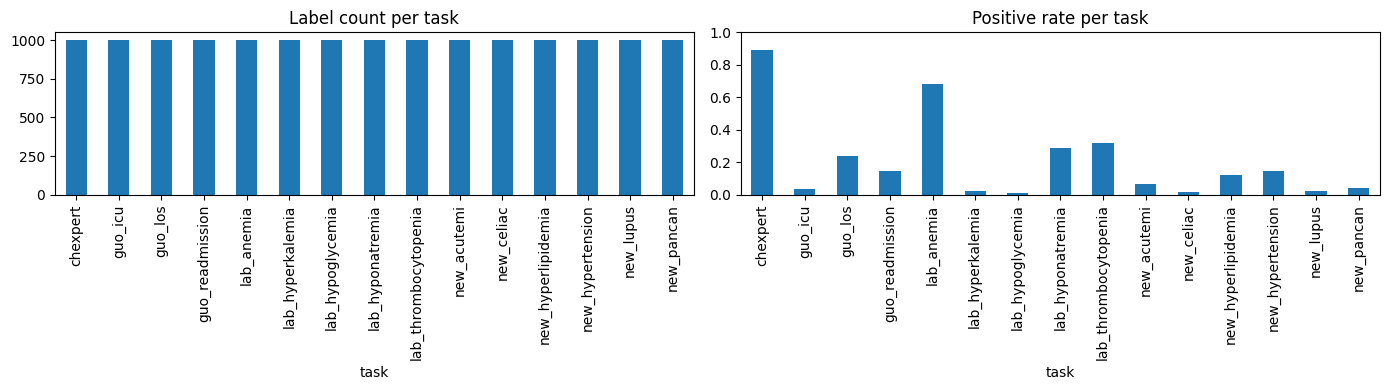

In [12]:
# 4) Label summary figure
summary = all_labels_full.groupby('task')['value'].agg(n='size', positive_rate='mean').sort_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
summary['n'].plot.bar(ax=axes[0], title='Label count per task')
summary['positive_rate'].plot.bar(ax=axes[1], title='Positive rate per task')
axes[1].set_ylim(0, 1)
plt.tight_layout()
plt.savefig(FIG_DIR / 'label_summary.png', dpi=180)
plt.show()


In [13]:
# 5) Per-task TrajGPT fine-tuning runner
def run_finetune_for_task(task: str, df_task: pd.DataFrame):
    all_labels_path = BENCH_DIR / 'all_labels.csv'
    df_task[['patient_id', 'prediction_time', 'label_type', 'value']].to_csv(all_labels_path, index=False)

    cmd = [
        sys.executable,
        str(ROOT / 'TrajGPT_Code' / 'run_finetune.py'),
        '--seq_len', str(SEQ_LEN),
        '--batch_size', str(BATCH_SIZE),
        '--train_epochs', str(EPOCHS),
    ]
    if CHECKPOINT_PATH is not None:
        cmd += ['--checkpoint_path', str(CHECKPOINT_PATH)]

    t0 = time.time()
    proc = subprocess.run(cmd, cwd=ROOT, capture_output=True, text=True)
    txt = (proc.stdout or '') + '\n' + (proc.stderr or '')
    log_tail = '\n'.join(txt.splitlines()[-40:])
    if proc.returncode != 0:
        raise RuntimeError(
            f'Fine-tune failed for task={task} with return code {proc.returncode}.\n{log_tail}'
        )
    auprc_txt = None
    for line in txt.splitlines():
        if line.startswith('Validation AUPRC:'):
            auprc_txt = line.split(':', 1)[1].strip()
    if auprc_txt is None:
        raise RuntimeError(f'Missing Validation AUPRC in output for task={task}.\n{log_tail}')
    auprc = np.nan if auprc_txt.lower() == 'nan' else float(auprc_txt)

    return {
        'task': task,
        'n_labels': int(len(df_task)),
        'positive_rate': float(df_task['value'].mean()),
        'val_auprc': auprc,
        'minutes': (time.time() - t0) / 60.0,
        'return_code': int(proc.returncode),
        'log_tail': log_tail,
    }

backup_path = BENCH_DIR / 'all_labels_original_backup.csv'
if (BENCH_DIR / 'all_labels.csv').exists() and not backup_path.exists():
    shutil.copy2(BENCH_DIR / 'all_labels.csv', backup_path)
    print('Backed up existing all_labels.csv ->', backup_path)


In [14]:
# 6) Run all benchmark tasks
results = []
for task in sorted(task_frames):
    print(f'\n=== {task} ===')
    res = run_finetune_for_task(task, task_frames[task])
    score_txt = f"{res['val_auprc']:.4f}" if pd.notna(res['val_auprc']) else 'nan'
    print(f"AUPRC={score_txt} | n={res['n_labels']} | pos={res['positive_rate']:.3f} | rc={res['return_code']} | {res['minutes']:.1f}m")
    results.append(res)

results_df = pd.DataFrame(results).sort_values('val_auprc', ascending=False)
results_df.to_csv(BENCH_DIR / 'benchmark_results.csv', index=False)
display(results_df[['task', 'val_auprc', 'n_labels', 'positive_rate', 'minutes', 'return_code']])



=== chexpert ===
AUPRC=0.9500 | n=1000 | pos=0.891 | rc=0 | 27.4m

=== guo_icu ===
AUPRC=0.0666 | n=1000 | pos=0.038 | rc=0 | 9.2m

=== guo_los ===
AUPRC=0.5322 | n=1000 | pos=0.236 | rc=0 | 4.4m

=== guo_readmission ===
AUPRC=0.3482 | n=1000 | pos=0.148 | rc=0 | 4.9m

=== lab_anemia ===
AUPRC=0.9378 | n=1000 | pos=0.682 | rc=0 | 7.3m

=== lab_hyperkalemia ===
AUPRC=0.0172 | n=1000 | pos=0.022 | rc=0 | 7.3m

=== lab_hypoglycemia ===
AUPRC=0.0159 | n=1000 | pos=0.013 | rc=0 | 8.7m

=== lab_hyponatremia ===
AUPRC=0.4530 | n=1000 | pos=0.290 | rc=0 | 6.9m

=== lab_thrombocytopenia ===
AUPRC=0.6132 | n=1000 | pos=0.321 | rc=0 | 6.7m

=== new_acutemi ===
AUPRC=0.2126 | n=1000 | pos=0.065 | rc=0 | 4.7m

=== new_celiac ===
AUPRC=0.0207 | n=1000 | pos=0.014 | rc=0 | 5.0m

=== new_hyperlipidemia ===
AUPRC=0.2396 | n=1000 | pos=0.121 | rc=0 | 4.4m

=== new_hypertension ===
AUPRC=0.3163 | n=1000 | pos=0.146 | rc=0 | 4.5m

=== new_lupus ===
AUPRC=0.4619 | n=1000 | pos=0.025 | rc=0 | 4.7m

=== new

,task,val_auprc,n_labels,positive_rate,minutes,return_code
0,chexpert,0.9500,1000,0.891,27.432757,0
4,lab_anemia,0.9378,1000,0.682,7.318768,0
8,lab_thrombocytopenia,0.6132,1000,0.321,6.727670,0
2,guo_los,0.5322,1000,0.236,4.417044,0
14,new_pancan,0.5259,1000,0.039,4.945743,0
13,new_lupus,0.4619,1000,0.025,4.691067,0
7,lab_hyponatremia,0.4530,1000,0.290,6.897886,0
3,guo_readmission,0.3482,1000,0.148,4.898824,0
12,new_hypertension,0.3163,1000,0.146,4.456514,0
11,new_hyperlipidemia,0.2396,1000,0.121,4.413664,0


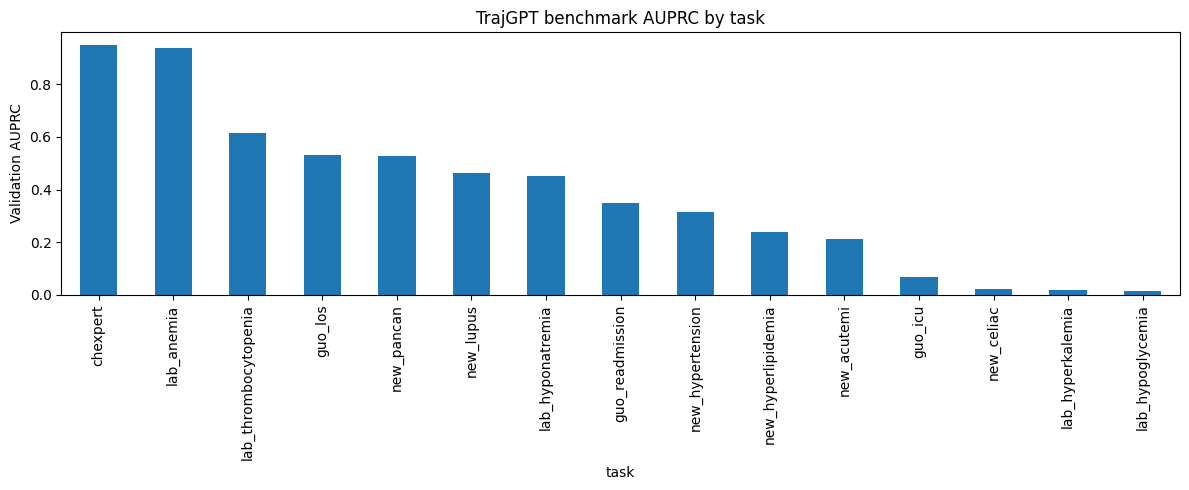

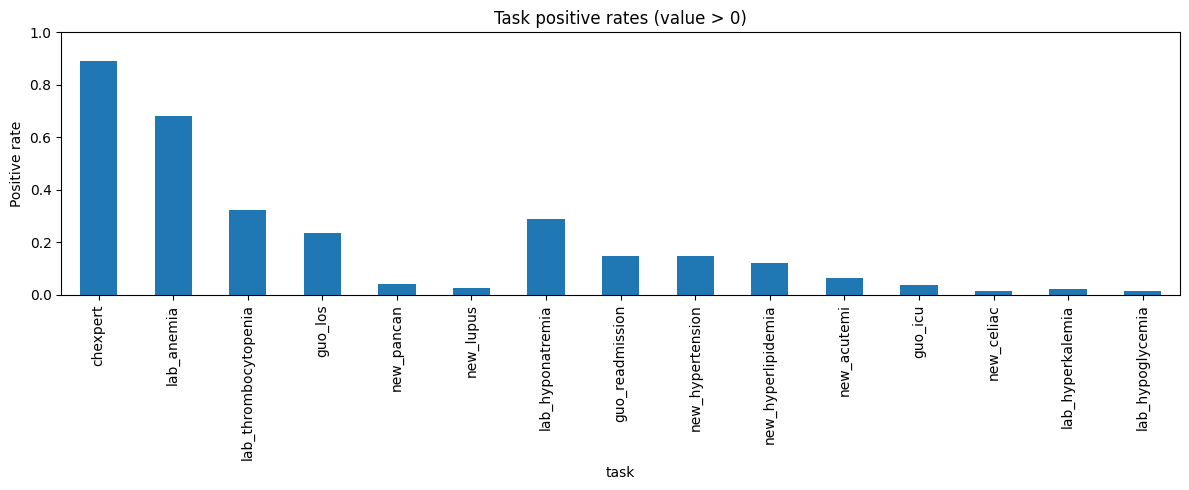

Saved:
- /Users/adrienbelanger/Library/GitHub/TrajGPT-EHRSHOT/benchmark/benchmark_results.csv
- /Users/adrienbelanger/Library/GitHub/TrajGPT-EHRSHOT/benchmark/figures/label_summary.png
- /Users/adrienbelanger/Library/GitHub/TrajGPT-EHRSHOT/benchmark/figures/benchmark_auprc.png
- /Users/adrienbelanger/Library/GitHub/TrajGPT-EHRSHOT/benchmark/figures/benchmark_positive_rate.png


In [15]:
# 7) Final benchmark figures
plot_df = results_df.set_index('task')

ax = plot_df['val_auprc'].plot.bar(figsize=(12, 5), title='TrajGPT benchmark AUPRC by task')
ax.set_ylabel('Validation AUPRC')
plt.tight_layout()
plt.savefig(FIG_DIR / 'benchmark_auprc.png', dpi=180)
plt.show()

ax = plot_df['positive_rate'].plot.bar(figsize=(12, 5), title='Task positive rates (value > 0)')
ax.set_ylabel('Positive rate')
ax.set_ylim(0, 1)
plt.tight_layout()
plt.savefig(FIG_DIR / 'benchmark_positive_rate.png', dpi=180)
plt.show()

print('Saved:')
print('-', BENCH_DIR / 'benchmark_results.csv')
print('-', FIG_DIR / 'label_summary.png')
print('-', FIG_DIR / 'benchmark_auprc.png')
print('-', FIG_DIR / 'benchmark_positive_rate.png')
